In [12]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone
import json
from tqdm import tqdm
from funcs import get_json



In [13]:
posts = get_json("posts_mini")
raw_user_data = get_json("userdata_mini")

In [64]:


# =====================================================
# Time utilities (timezone-safe)
# =====================================================

def parse_dt(ts):
    if not ts:
        return None
    try:
        return datetime.fromisoformat(
            ts.replace("Z", "+00:00")
        ).astimezone(timezone.utc)
    except Exception:
        return None




# =====================================================
# History-based features
# =====================================================

def history_stats(history, exclude_post_id):

    if not history:
        print("No history for this user")
        return 0.0, None, 0, 0, 0, 0

    # ===============================
    #  RetweetPercent (exclude current post)
    # ===============================
    hist_len_wo_current = sum(1 for h in history if h.get("post_uri") != exclude_post_id)

    reposts = sum(
        1 for h in history
        if h.get("activity_type") == "repost"
        and h.get("post_uri") != exclude_post_id
    )
    repost_pct = reposts / hist_len_wo_current



    # ===============================
    #  AverageInterval 
    # ===============================
    times = []

    for h in history:
        if h.get("activity_type") == "repost":
            ts = h.get("reposted_at")
        else:
            ts = h.get("created_at")

        times.append(parse_dt(ts))

    if len(times) >= 2:
        times.sort()
        oldest = times[0]
        latest = times[-1]

        total_span_days = (latest - oldest).total_seconds() / 86400
        avg_interval = total_span_days / (len(times) - 1)
    else:
        avg_interval = None


    # =============================== 
    #  Avg Engagement 
    # ===============================
    total_likes = 0
    total_reposts = 0
    total_replies = 0
    total_quotes = 0
    post_count = 0

    for h in history:
        if h.get("activity_type") == "post":
            total_likes += h.get("like_count")
            total_reposts += h.get("repost_count")
            total_replies += h.get("reply_count")
            total_quotes += h.get("quote_count")
            post_count += 1

    if post_count > 0:
        HU_R_LikedRate = total_likes / post_count
        HU_R_RetweetedRate = total_reposts / post_count
        HU_R_RepliedRate = total_replies / post_count
        HU_R_QuotedRate = total_quotes / post_count
    else:
        HU_R_LikedRate = 0
        HU_R_RetweetedRate = 0
        HU_R_RepliedRate = 0
        HU_R_QuotedRate = 0

    return (
        repost_pct,
        avg_interval,
        HU_R_RetweetedRate,
        HU_R_QuotedRate,
        HU_R_RepliedRate,
        HU_R_LikedRate,
    )




def mention_stats(history, handle, exclude_post_id=None):

    if not history or not handle:
        return 0, 0.0

    total = len(history)
    count = sum(
        handle in h.get("text")
        for h in history
        if h.get("post_uri") != exclude_post_id
    )

    return count, count / total


def reposts_from_author(history, author_did, exclude_post_id=None):

    return sum(
        1
        for h in history
        if h.get("activity_type") == "repost"
        and h.get("post_author_did") == author_did 
        and h.get("post_uri") != exclude_post_id
    )


# =====================================================
# User feature extraction
# =====================================================

def user_profile_features(user, max_posts, prefix):

    age = user["stats"]["account_age_days"] 
    posts = user["stats"]["posts"] 

    return {
        f"U-P_{prefix}_AccountAge": age,
        f"U-P_{prefix}_FollowerNum": user["stats"]["followers"],
        f"U-P_{prefix}_FolloweeNum": user["stats"]["follows"],
        f"U-P_{prefix}_TweetNum": posts,
        f"U-P_{prefix}_SpreadActivity": posts / max_posts,
        f"U-P_{prefix}_FollowerNumDay": user["stats"]["followers"] / age,
        f"U-P_{prefix}_FolloweeNumDay": user["stats"]["follows"] / age,
        f"U-P_{prefix}_TweetNumDay": posts / age,
        f"U-P_{prefix}_ProfileUrl":
            int("http" in (user["profile"]["description"] or "")),
    }


def user_history_features(user, exclude_post_id, prefix):

    repost_pct, avg_interval, retweetedRate, quotedRate, repliedRate, likedRate, = history_stats(
        user["history"],
        exclude_post_id
    )

    return {
        f"U-HA_{prefix}_RetweetPercent": repost_pct,
        f"U-HA_{prefix}_AverageInterval": avg_interval,
        f"U-HA_{prefix}_RetweetedRate": retweetedRate,
        f"U-HA_{prefix}_QuotedRate": quotedRate,
        f"U-HA_{prefix}_RepliedRate": repliedRate,
        f"U-HA_{prefix}_LikedRate": likedRate,
        f"U-HA_{prefix}_TweetNum": len(user["history"])
    }



# =====================================================
# Unified Row Builder
# =====================================================

def build_row(A_id, S_id, P_id, post, users, max_posts, label):

    A = users[A_id]
    S = users[S_id]

    P_time = parse_dt(post.get("indexedAt"))   # this should be fine
    if not P_time:
        return None

    hashtag = post.get("hashtag")

    # Profile features
    A_profile = user_profile_features(A, max_posts, "R")
    S_profile = user_profile_features(S, max_posts, "S")

    # History features
    A_hist = user_history_features(A, P_time, "R")
    S_hist = user_history_features(S, P_time, "S")

    # Mentions
    A_m_S, A_m_S_per = mention_stats(
        A["history"],
        S["profile"]["handle"],
        exclude_post_id=P_id,
    )

    S_m_A, S_m_A_per = mention_stats(
        S["history"],
        A["profile"]["handle"],
        exclude_post_id=P_id,
    )



    row = {
        "A_id": A_id,
        "S_id": S_id,
        "P_id": P_id,
        "hashtag": hashtag,
        "label": label,

        # Interaction features
        "U-P_R_FollowS": int(S_id in A.get("follows_authors", [])),
        "U-HA_R_MentionS": A_m_S,
        "U-HA_R_MentionPerS": A_m_S_per,
        "U-HA_S_MentionR": S_m_A,
        "U-HA_S_MentionPerR": S_m_A_per,
        "U-HA-R_repostsS":
            reposts_from_author(
                A["history"], S_id, exclude_post_id=P_id
            ),
        "U-P_SR_followersDiff":
            S["stats"]["followers"] - A["stats"]["followers"],
        "U-P_R_activeBeforeP":
            int(parse_dt(A["profile"].get("created_at")) < P_time)
            if A["profile"].get("created_at") else 0,
    }

    row.update(A_profile)
    row.update(S_profile)
    row.update(A_hist)
    row.update(S_hist)

    return row


# =====================================================
# FINAL DATASET BUILDER
# =====================================================

def build_dataset(
    users,
    posts_dict,
    neg_per_pos,
):

    rng = np.random.default_rng()
    all_users = set(users.keys())
    post_items = list(posts_dict.items())

    max_posts = max(
        u["stats"]["posts"] or 1
        for u in users.values()
    )

    rows = []

    for P_id, post in tqdm(post_items, desc="Building Dataset"):

        S_id = post.get("author").get("did")
        if not S_id or S_id not in users:
            continue

        reposted_by = post.get("reposted_by")
        if not reposted_by:
            continue
        stored_reposters = post.get("stored_reposters")

        A_id = reposted_by[0] #temp

        if A_id not in users:
            print("fuck")
            continue

        pos_row = build_row(
            A_id, S_id, P_id,
            post, users, max_posts,
            label=1
        )

        if pos_row:
            rows.append(pos_row)

        candidate_users = all_users - {S_id}
        neg_pool = list(candidate_users - set(reposted_by))

        if neg_pool:
            negs = rng.choice(
                neg_pool,
                size=min(neg_per_pos, len(neg_pool)),
                replace=False,
            )

            for neg_A in negs:
                neg_row = build_row(
                    neg_A, S_id, P_id,
                    post, users, max_posts,
                    label=0
                )
                if neg_row:
                    rows.append(neg_row)

    return pd.DataFrame(rows)


In [ ]:
# we decided to include history before and after post under consideration as history distribution is assumed constant for each user. but we do exclude the post under consideration.

In [ ]:
def remove_pair_duplicates(df):
    # Drop duplicate S_id, A_id pairs
    df_clean = df.drop_duplicates(subset=["S_id", "A_id"])
    return df_clean

In [66]:
for i in range(2,10):
    df = build_dataset(
        raw_user_data,
        posts,
        neg_per_pos=1
    )

    df = remove_pair_duplicates(df)
    df.to_csv(f"mini_1:1_#{i}.csv", index=False)

Building Dataset:  25%|██▌       | 29333/116003 [00:57<03:42, 390.13it/s] 

fuck


Building Dataset:  52%|█████▏    | 60708/116003 [01:52<00:58, 950.74it/s] 

fuck


Building Dataset:  25%|██▌       | 29336/116003 [00:56<03:47, 380.16it/s] 

...

Building Dataset:  25%|██▌       | 29332/116003 [00:57<03:38, 396.51it/s] 

fuck


Building Dataset:  52%|█████▏    | 60707/116003 [01:53<00:58, 951.88it/s] 

fuck


Building Dataset: 100%|██████████| 116003/116003 [03:42<00:00, 520.34it/s]


In [67]:
for i in range(1,10):
    df = build_dataset(
        raw_user_data,
        posts,
        neg_per_pos=5
    )

    df = remove_pair_duplicates(df)
    df.to_csv(f"mini_1:5_#{i}.csv", index=False)

Building Dataset:  25%|██▌       | 29308/116003 [00:57<03:38, 397.35it/s] 

fuck


Building Dataset:  52%|█████▏    | 60748/116003 [01:53<00:55, 1003.75it/s]

fuck


Building Dataset:  72%|███████▏  | 83476/116003 [02:32<00:55, 585.92it/s] 

...

Building Dataset:  52%|█████▏    | 60747/116003 [09:56<00:54, 1009.71it/s]

fuck


Building Dataset:  68%|██████▊   | 78868/116003 [10:28<01:16, 483.27it/s] 

No history for this user


Building Dataset: 100%|██████████| 116003/116003 [11:48<00:00, 163.66it/s]


In [68]:
print(df.columns.unique)

<bound method Index.unique of Index(['A_id', 'S_id', 'P_id', 'hashtag', 'label', 'U-P_R_FollowS',
       'U-HA_R_MentionS', 'U-HA_R_MentionPerS', 'U-HA_S_MentionR',
       'U-HA_S_MentionPerR', 'U-HA-R_repostsS', 'U-P_SR_followersDiff',
       'U-P_R_activeBeforeP', 'U-P_R_AccountAge', 'U-P_R_FollowerNum',
       'U-P_R_FolloweeNum', 'U-P_R_TweetNum', 'U-P_R_SpreadActivity',
       'U-P_R_FollowerNumDay', 'U-P_R_FolloweeNumDay', 'U-P_R_TweetNumDay',
       'U-P_R_ProfileUrl', 'U-P_S_AccountAge', 'U-P_S_FollowerNum',
       'U-P_S_FolloweeNum', 'U-P_S_TweetNum', 'U-P_S_SpreadActivity',
       'U-P_S_FollowerNumDay', 'U-P_S_FolloweeNumDay', 'U-P_S_TweetNumDay',
       'U-P_S_ProfileUrl', 'U-HA_R_RetweetPercent', 'U-HA_R_AverageInterval',
       'U-HA_R_RetweetedRate', 'U-HA_R_QuotedRate', 'U-HA_R_RepliedRate',
       'U-HA_R_LikedRate', 'U-HA_R_TweetNum', 'U-HA_S_RetweetPercent',
       'U-HA_S_AverageInterval', 'U-HA_S_RetweetedRate', 'U-HA_S_QuotedRate',
       'U-HA_S_RepliedRate', 'U

In [45]:
def count_pairs(df):
    return df[["A_id", "S_id"]].drop_duplicates().shape[0]

def count_S_and_A(df):
    print(f"Unique #R: {df[['A_id']].drop_duplicates().shape[0]}")
    print(f"Unique #S: {df[['S_id']].drop_duplicates().shape[0]}")



print(f"Unique number of (S,R) pairs in dataframe: {count_pairs(df)}")
print(f" Total number of pairs: {df.shape[0]}")
count_S_and_A(df)


Unique number of (S,R) pairs in dataframe: 67983
 Total number of pairs: 67983
Unique #R: 31974
Unique #S: 14631


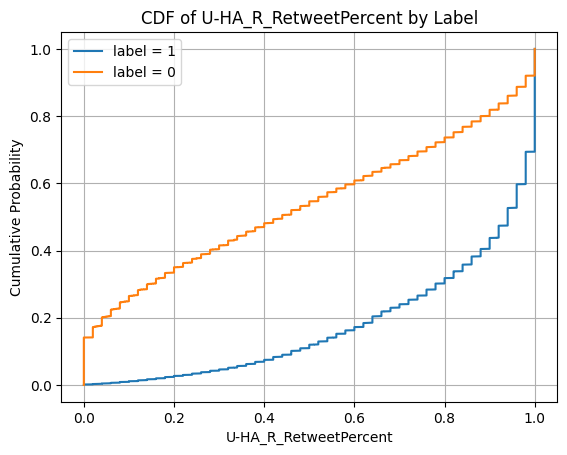

In [46]:
import matplotlib.pyplot as plt

def plot_cdf_by_label(df, column, x_max=None, title=None):
    """
    Plots the empirical CDF of a column
    split by label (0 vs 1).

    Parameters:
    -----------
    df : pandas.DataFrame
    column : str
        Name of numeric column to plot
    x_max : float or None
        Optional upper limit for x-axis
    title : str or None
        Optional custom title
    """

    # Remove missing values
    df_clean = df.dropna(subset=[column, "label"])

    # Split by label
    pos = df_clean[df_clean["label"] == 1][column].values
    neg = df_clean[df_clean["label"] == 0][column].values

    # Sort
    pos_sorted = np.sort(pos)
    neg_sorted = np.sort(neg)

    # Compute empirical CDF
    pos_cdf = (
        np.arange(1, len(pos_sorted) + 1) / len(pos_sorted)
        if len(pos_sorted) > 0 else None
    )

    neg_cdf = (
        np.arange(1, len(neg_sorted) + 1) / len(neg_sorted)
        if len(neg_sorted) > 0 else None
    )

    # Plot
    plt.figure()

    if pos_cdf is not None:
        plt.plot(pos_sorted, pos_cdf)

    if neg_cdf is not None:
        plt.plot(neg_sorted, neg_cdf)

    plt.xlabel(column)
    plt.ylabel("Cumulative Probability")

    if title:
        plt.title(title)
    else:
        plt.title(f"CDF of {column} by Label")

    plt.legend(["label = 1", "label = 0"])
    plt.grid(True)

    if x_max is not None:
        plt.xlim(0, x_max)

    plt.show()

plot_cdf_by_label(df, "U-HA_R_RetweetPercent")#, x_max=10)


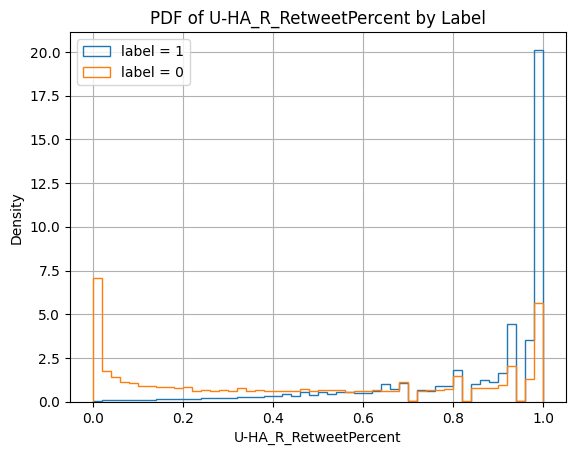

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pdf_by_label(df, column, bins=50, x_max=None, title=None):
    """
    Plots the empirical PDF (density histogram)
    of a column split by label (0 vs 1).
    """


    pos = df[df["label"] == 1][column].values
    neg = df[df["label"] == 0][column].values

    plt.figure()

    if len(pos) > 0:
        plt.hist(pos, bins=bins, density=True, histtype='step', label="label = 1")

    if len(neg) > 0:
        plt.hist(neg, bins=bins, density=True, histtype='step', label="label = 0")

    plt.xlabel(column)
    plt.ylabel("Density")

    if title:
        plt.title(title)
    else:
        plt.title(f"PDF of {column} by Label")

    if x_max is not None:
        plt.xlim(0, x_max)

    plt.legend()
    plt.grid(True)
    plt.show()

plot_pdf_by_label(df, "U-HA_R_RetweetPercent")#, x_max=10)


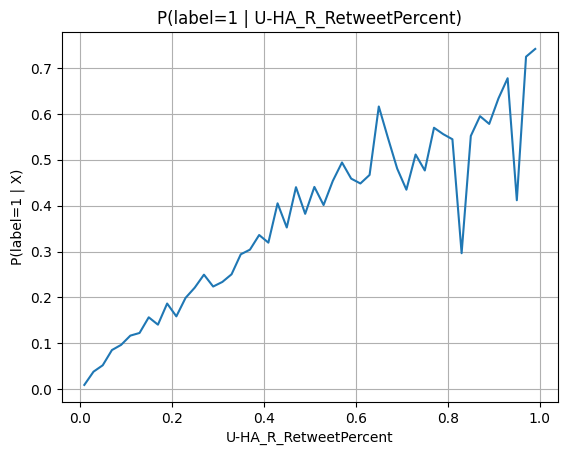

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def plot_p_label_given_x(df, column, bins=50, x_max=None, title=None):
    """
    Plots P(label=1 | X) using binning.
    """

    x = df[column].values
    y = df["label"].values

    # Optional clipping
    if x_max is not None:
        mask = x <= x_max
        x = x[mask]
        y = y[mask]

    # Create bins
    bin_edges = np.linspace(np.min(x), np.max(x), bins + 1)
    bin_indices = np.digitize(x, bin_edges) - 1

    prob = []
    bin_centers = []

    for i in range(bins):
        mask = bin_indices == i
        if np.sum(mask) > 0:
            p = np.mean(y[mask])  # fraction of label=1
            prob.append(p)
            bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)

    plt.figure()
    plt.plot(bin_centers, prob)
    plt.xlabel(column)
    plt.ylabel("P(label=1 | X)")
    
    if title:
        plt.title(title)
    else:
        plt.title(f"P(label=1 | {column})")

    plt.grid(True)
    plt.show()
plot_p_label_given_x(df, "U-HA_R_RetweetPercent")